# Coronary Stenosis — Data Exploration
**Input:** `roi_features_subset_b.csv` produced by the 1498-image feature extraction pipeline.

**Key facts about the CSV structure:**
- `roi_name` = `{patient_id}_{serie_id}_{frame}_{roi_idx}` where `roi_idx` ∈ [1, 100] are skeleton-sampled ROIs and `roi_idx ≥ 101` are forced GT-centred boxes (always stenosis=1 — must be **excluded from the test split**)
- 2191 feature columns: 30 raw (global + 4 tiles × 6 stats) + 2160 Gabor (72 filters × 30) + 1 `width_ratio`
- Target: `label` — 1 = stenosis, 0 = healthy

## 0. Imports & config

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from matplotlib.patches import Patch
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

CSV_PATH  = r"C:\Users\mluser\IPA_ML\notebooks\notebooks\csv_files\oriented_rois\roi_oriented_features_subset_1498.csv"

TILE_LABELS = ['tl', 'tr', 'bl', 'br']
N_SIZES        = 6
N_ORIENTATIONS = 12
N_FILTERS      = N_SIZES * N_ORIENTATIONS  # 72

META_COLS   = ['roi_name']
TARGET_COL  = 'label'

# ROI index threshold: roi_idx > FORCED_ROI_THRESHOLD are forced GT boxes
FORCED_ROI_THRESHOLD = 100

## 1. Load & parse roi_name

In [2]:
df_all = pd.read_csv(CSV_PATH)

# Parse roi_name → patient_id, serie_id, frame_id, roi_idx
def parse_roi_name(name):
    parts      = str(name).split('_')
    patient_id = parts[0]    # '002'
    serie_id   = parts[1]    # '5'
    frame_id   = parts[5]    # '0034'
    roi_idx    = int(parts[-1])  # 1
    return patient_id, serie_id, frame_id, roi_idx

parsed = df_all['roi_name'].apply(parse_roi_name)
df_all[['patient_id','serie_id','frame_id','roi_idx']] = pd.DataFrame(
    parsed.tolist(), index=df_all.index
)

# Flag forced GT boxes (roi_idx > 100)
df_all['is_forced_gt'] = df_all['roi_idx'] > FORCED_ROI_THRESHOLD

feature_cols = [c for c in df_all.columns
                if c not in META_COLS + [TARGET_COL,
                   'patient_id','serie_id','frame_id','roi_idx','is_forced_gt']]

print(f'Total ROIs        : {len(df_all):,}')
print(f'  skeleton-sampled: {(~df_all.is_forced_gt).sum():,}')
print(f'  forced GT boxes : {df_all.is_forced_gt.sum():,}')
print(f'Feature columns   : {len(feature_cols)}')
print(f'Unique patients   : {df_all.patient_id.nunique()}')
print(f'Unique series     : {df_all.serie_id.nunique()}')
df_all.head(3)

Total ROIs        : 151,298
  skeleton-sampled: 149,800
  forced GT boxes : 1,498
Feature columns   : 1398
Unique patients   : 64
Unique series     : 21


,roi_name,image_name,center_x,center_y,angle,width,height,label,gabor_f0_global_mean,gabor_f0_global_var,...,lbp_r2_bin14,lbp_r2_bin15,lbp_r2_bin16,lbp_r2_bin17,width_ratio,patient_id,serie_id,frame_id,roi_idx,is_forced_gt
0,002_5_14_002_5_0031_1,002_5_14_002_5_0031,188,104,138.366461,100,50,0,101.138161,25136.062500,...,0.0186,0.0118,0.0242,0.1000,51.0,002,5,0031,1,False
1,002_5_14_002_5_0031_2,002_5_14_002_5_0031,184,105,143.130102,100,50,0,99.224960,41409.835938,...,0.0170,0.0126,0.0228,0.0906,58.0,002,5,0031,2,False
2,002_5_14_002_5_0031_3,002_5_14_002_5_0031,182,105,0.000000,100,50,0,99.958427,176076.953125,...,0.0166,0.0116,0.0254,0.1030,71.0,002,5,0031,3,False


## 2. df information and series selection

In [3]:
# 1 random serie per patient selection
selected_series = (
    df_all.groupby('patient_id')['serie_id']
    .apply(lambda s: s.drop_duplicates()
                      .sample(n=1, random_state=RANDOM_STATE)
                      .iloc[0])
    .reset_index()
    .rename(columns={'serie_id': 'selected_serie'})
)

df = df_all.merge(
    selected_series,
    left_on  = ['patient_id', 'serie_id'],
    right_on = ['patient_id', 'selected_serie']
).drop(columns='selected_serie').reset_index(drop=True)

sampled = df[~df.is_forced_gt].copy()

print(f'Before : {len(df_all):,} ROIs — {df_all.groupby(["patient_id","serie_id"]).ngroups} series')
print(f'After: {len(df):,} ROIs — {df.patient_id.nunique()} patients × 1 serie')

Before : 151,298 ROIs — 214 series
After: 45,248 ROIs — 64 patients × 1 serie


In [4]:
df[feature_cols + [TARGET_COL]].info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45248 entries, 0 to 45247
Columns: 1399 entries, image_name to label
dtypes: float64(1393), int64(5), object(1)
memory usage: 483.0+ MB


In [5]:
df[feature_cols].describe().T \
    .sort_values('std', ascending=False) \
    .head(20)

,count,mean,std,min,25%,50%,75%,max
gabor_f53_global_energy,45248.0,1.176450e+10,9.540493e+09,92909656.0,5.123162e+09,9.061749e+09,1.548408e+10,9.725374e+10
gabor_f29_global_energy,45248.0,1.183074e+10,9.507317e+09,109007424.0,5.192706e+09,9.040718e+09,1.565710e+10,1.166028e+11
gabor_f17_global_energy,45248.0,8.280595e+09,7.594682e+09,58886064.0,3.021804e+09,6.045166e+09,1.101514e+10,7.637597e+10
gabor_f65_global_energy,45248.0,8.224466e+09,7.517531e+09,65262276.0,3.016252e+09,6.049211e+09,1.095234e+10,8.841470e+10
gabor_f29_left_energy,45248.0,5.872493e+09,5.582450e+09,35655128.0,2.192285e+09,4.115015e+09,7.593361e+09,8.151463e+10
gabor_f53_left_energy,45248.0,5.784000e+09,5.561673e+09,45157308.0,2.126672e+09,4.022933e+09,7.435644e+09,6.523508e+10
gabor_f53_right_energy,45248.0,5.507084e+09,5.322324e+09,57313476.0,1.972673e+09,3.832516e+09,7.169717e+09,6.626052e+10
gabor_f29_right_energy,45248.0,5.477796e+09,5.277573e+09,56715280.0,1.983463e+09,3.788690e+09,7.067697e+09,6.192599e+10
gabor_f17_left_energy,45248.0,4.117244e+09,4.665934e+09,25729374.0,1.228573e+09,2.600074e+09,5.175023e+09,5.703057e+10
gabor_f65_left_energy,45248.0,4.064417e+09,4.514279e+09,30565874.0,1.245895e+09,2.629421e+09,5.109166e+09,6.184140e+10


## 3. Missing values

In [12]:
nan_per_col = df[feature_cols].isna().sum()
nan_pct     = nan_per_col / len(df) * 100
nan_df      = pd.DataFrame({'n_missing': nan_per_col, 'pct_missing': nan_pct})
nan_df      = nan_df[nan_df.n_missing > 0].sort_values('pct_missing', ascending=False)

print(f'Features with NaNs: {len(nan_df)} / {len(feature_cols)}')

if len(nan_df):
    display(nan_df.head(20))
    # NaN rows by class & forced-GT flag
    nan_rows = df[df[feature_cols].isna().any(axis=1)]
    print('\nNaN rows by label:')
    print(nan_rows[TARGET_COL].value_counts().rename({0:'Healthy',1:'Stenosis'}))
    print('\nNaN rows are forced GT?')
    print(nan_rows['is_forced_gt'].value_counts())

    # Most problematic features
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.bar(range(len(nan_df)), nan_df.pct_missing, color='#E85D24', alpha=0.8)
    ax.set_xlabel('Feature (sorted by % missing)')
    ax.set_ylabel('% missing')
    ax.set_title('Missing values per feature')
    plt.tight_layout(); plt.show()
else:
    print('No missing values.')

Features with NaNs: 0 / 1398
No missing values.


## 4. Forced GT boxes the test-split contamination issue

ROIs with `roi_idx > 100` are forced GT-centred boxes injected during extraction so that every stenosis always has at least one positive ROI. They should **always label=1 by construction** and must be **removed from the test split** (they are not blind predictions, the model would see data it was designed to find).

Below we verify their properties and create the clean training-eligible DataFrame.

In [13]:
forced  = df[df.is_forced_gt]
sampled = df[~df.is_forced_gt]

print('=== Forced GT boxes (roi_idx > 100) ===')
print(f'  Count                : {len(forced):,}')
print(f'  label=1 (stenosis)   : {forced[TARGET_COL].sum():,}  ({forced[TARGET_COL].mean()*100:.1f}%)')
print(f'  label=0 (healthy)    : {(forced[TARGET_COL]==0).sum():,}')
print()
print('=== Skeleton-sampled ROIs (roi_idx 1-100) ===')
print(f'  Count                : {len(sampled):,}')
print(f'  label=1 (stenosis)   : {sampled[TARGET_COL].sum():,}  ({sampled[TARGET_COL].mean()*100:.2f}%)')
print(f'  label=0 (healthy)    : {(sampled[TARGET_COL]==0).sum():,}')
print()

=== Forced GT boxes (roi_idx > 100) ===
  Count                : 448
  label=1 (stenosis)   : 418  (93.3%)
  label=0 (healthy)    : 12

=== Skeleton-sampled ROIs (roi_idx 1-100) ===
  Count                : 44,800
  label=1 (stenosis)   : -798  (-1.78%)
  label=0 (healthy)    : 39,532



## 5. Class distribution

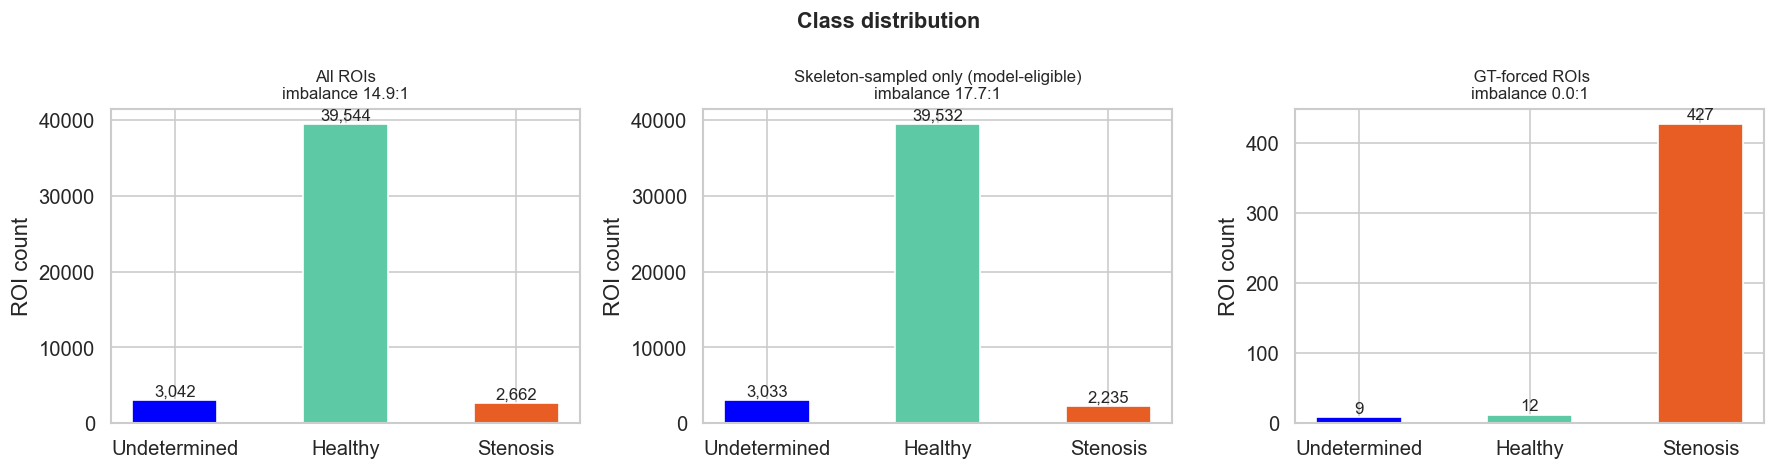

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

COLORS = {'Healthy': '#5DCAA5', 'Stenosis': '#E85D24', 'Undetermined': 'blue'}

for ax, subset, title in zip(
    axes,
    [df, sampled, forced],
    ['All ROIs', 'Skeleton-sampled only (model-eligible)', ' GT-forced ROIs']
):
    vc = subset[TARGET_COL].value_counts().sort_index()
    labels_map = {0:'Healthy', 1:'Stenosis', -1:'Undetermined'}
    names  = [labels_map[k] for k in vc.index]
    counts = vc.values
    colors = [COLORS[n] for n in names]
    bars = ax.bar(names, counts, color=colors, width=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(subset)*0.003,
                f'{count:,}', ha='center', va='bottom', fontsize=10)
    ratio = vc.get(0, 0) / max(vc.get(1, 1), 1)
    ax.set_title(f'{title}\nimbalance {ratio:.1f}:1', fontsize=10)
    ax.set_ylabel('ROI count')

plt.suptitle('Class distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Patients with ZERO stenosis ROIs (skeleton-sampled): 1



,n_total,n_healthy,n_stenosis
patient_id,,,
091,700,700,0


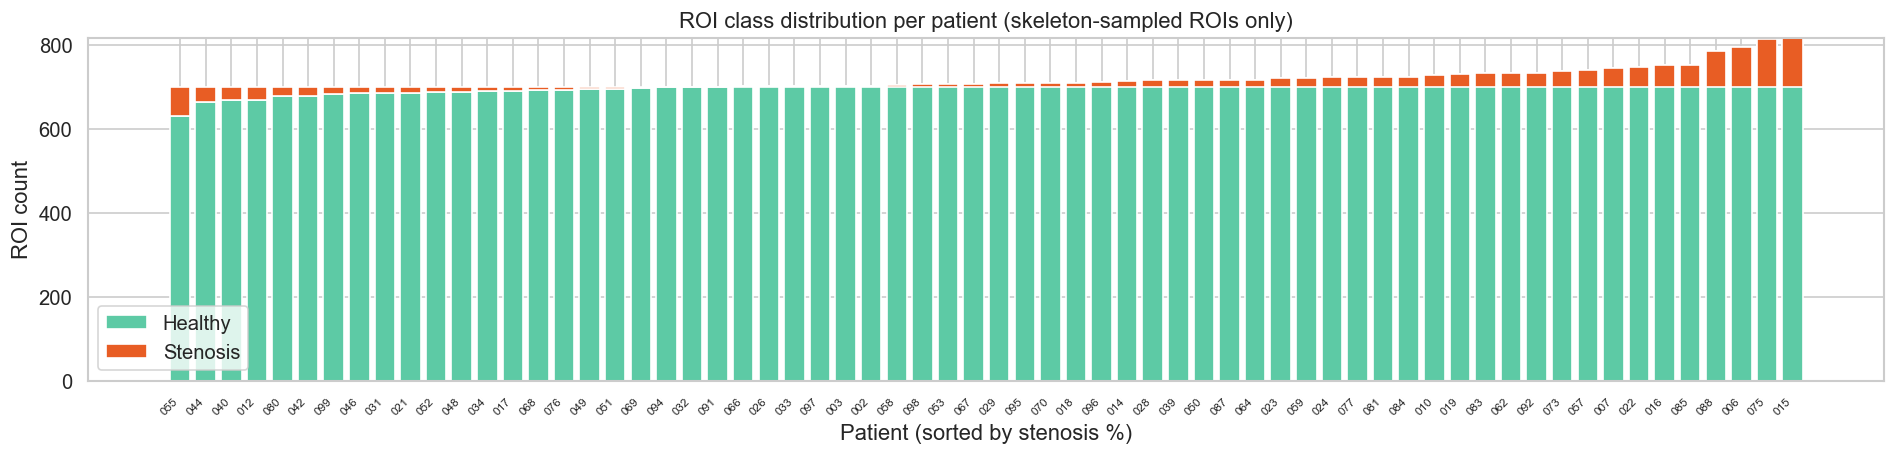

In [15]:
# Per-patient stenosis ROI count (skeleton-sampled only)
per_patient = sampled.groupby('patient_id')[TARGET_COL].agg(
    n_stenosis='sum', n_total='count'
)
per_patient['n_healthy']    = per_patient.n_total - per_patient.n_stenosis
per_patient['stenosis_pct'] = per_patient.n_stenosis / per_patient.n_total * 100

zero_stenosis_patients = (per_patient.n_stenosis == 0).sum()
print(f'Patients with ZERO stenosis ROIs (skeleton-sampled): {zero_stenosis_patients}')
print()
display(per_patient[per_patient.n_stenosis == 0][['n_total','n_healthy','n_stenosis']])

fig, ax = plt.subplots(figsize=(16, 4))
per_patient_sorted = per_patient.sort_values('stenosis_pct', ascending=False)
x = range(len(per_patient_sorted))
ax.bar(x, per_patient_sorted.n_healthy,  color='#5DCAA5', label='Healthy')
ax.bar(x, per_patient_sorted.n_stenosis, bottom=per_patient_sorted.n_healthy,
       color='#E85D24', label='Stenosis')
ax.set_xticks(list(x))
ax.set_xticklabels(per_patient_sorted.index, rotation=45, ha='right', fontsize=7)
ax.set_xlabel('Patient (sorted by stenosis %)')
ax.set_ylabel('ROI count')
ax.set_title('ROI class distribution per patient (skeleton-sampled ROIs only)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature group breakdown

Column naming convention: `raw_global_{stat}`, `raw_{tile}_{stat}`, `gabor_f{i}_global_{stat}`, `gabor_f{i}_{tile}_{stat}`, `width_ratio`

In [16]:
def classify_col(col):
    if col == 'width_ratio':
        return 'raw', 'width_ratio', 'width_ratio'
    parts  = col.split('_')
    source = parts[0]       
    return source

meta_df = pd.DataFrame(
    [classify_col(c) for c in feature_cols],
    columns=['source'],
    index=feature_cols
)

print('Feature count by source:')
print(meta_df.source.value_counts().to_string())
print()

Feature count by source:
source
gabor                              1296
paper                                49
lbp                                  28
raw                                  18
center                                2
image                                 1
height                                1
width                                 1
angle                                 1
(raw, width_ratio, width_ratio)       1



## 7. ANOVA F-test - univariate feature ranking

In [17]:
# Metadata columns to exclude
META_COLS = ['roi_name', 'image_name', 'center_x', 'center_y',
             'angle', 'width', 'height', 'label',
             'patient_id', 'serie_id', 'frame_id', 'roi_idx', 'is_forced_gt']

feature_cols = [c for c in sampled.columns if c not in META_COLS]

# Verificar que todas son numéricas
print(f"Feature columns: {len(feature_cols)}")
print(f"Non-numeric: {sampled[feature_cols].select_dtypes(exclude='number').columns.tolist()}")

# Ahora sí
X_sampled = sampled[feature_cols].fillna(sampled[feature_cols].median())
y_sampled = sampled[TARGET_COL]

f_scores, p_values = f_classif(X_sampled, y_sampled)

anova_df = pd.DataFrame({
    'feature': feature_cols,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False).reset_index(drop=True)

sig = (anova_df.p_value < 0.05).sum()
print(f'Features significant at p<0.05: {sig} / {len(feature_cols)}')
print(f'\nTop 20 by ANOVA F-score:')
display(anova_df.head(20))

Feature columns: 1392
Non-numeric: []
Features significant at p<0.05: 1089 / 1392

Top 20 by ANOVA F-score:


,feature,F_score,p_value
0,raw_global_var,715.077547,1.995181e-306
1,paper_px_std,667.890094,1.511894e-286
2,paper_haralick_sum_entropy,642.732238,6.235454e-276
3,raw_left_var,621.858781,4.085226e-267
4,paper_haralick_entropy,621.408853,6.329078e-267
5,lbp_r2_bin11,543.049662,9.335638e-234
6,paper_haralick_imc2,535.056994,2.289496e-230
7,gabor_f53_global_energy,531.587349,6.784895e-229
8,gabor_f53_global_var,531.128894,1.061778e-228
9,paper_haralick_variance,518.997346,1.492862e-223


C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\mluser\miniconda3\envs\DL_MIC\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Pass

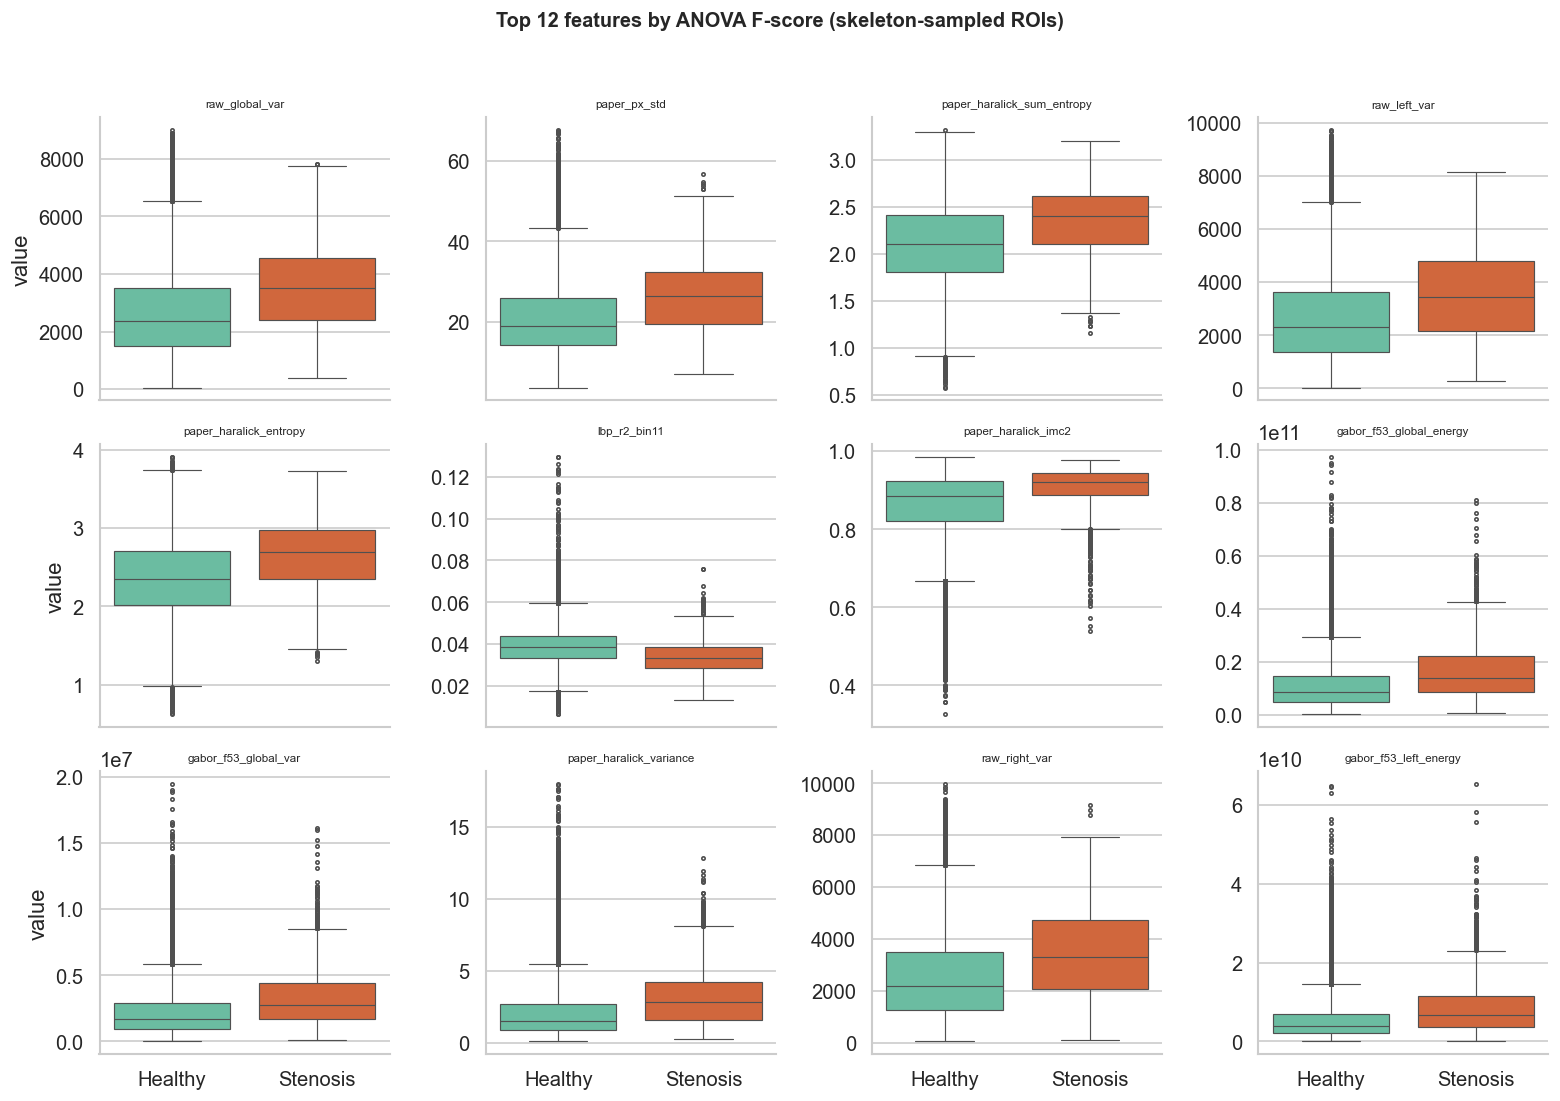

In [47]:
# Boxplots for top 12 features
top12 = anova_df.head(12).feature.tolist()
plot_df = sampled[top12 + [TARGET_COL]].melt(id_vars=TARGET_COL, var_name='feature', value_name='value')
plot_df['class'] = plot_df[TARGET_COL].map({0:'Healthy', 1:'Stenosis'})

g = sns.FacetGrid(plot_df, col='feature', col_wrap=4, height=3, aspect=1.1, sharey=False)
g.map_dataframe(sns.boxplot, x='class', y='value',
                palette={'Healthy':'#5DCAA5','Stenosis':'#E85D24'},
                linewidth=0.7, fliersize=2)
g.set_titles(col_template='{col_name}', size=7)
g.set_axis_labels('', 'value')
plt.suptitle('Top 12 features by ANOVA F-score (skeleton-sampled ROIs)', y=1.02,
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Selection with Random Forest

Real split : 75.0% / 25.0%
Train ROIs : 33,936  (label=1: 2,108, label=-1: 2,461)
Test ROIs  : 11,200   (label=1: 455, label=-1: 580)
Train patients: 48 | Test patients: 16
Leakage check: 0 patients in both ✓


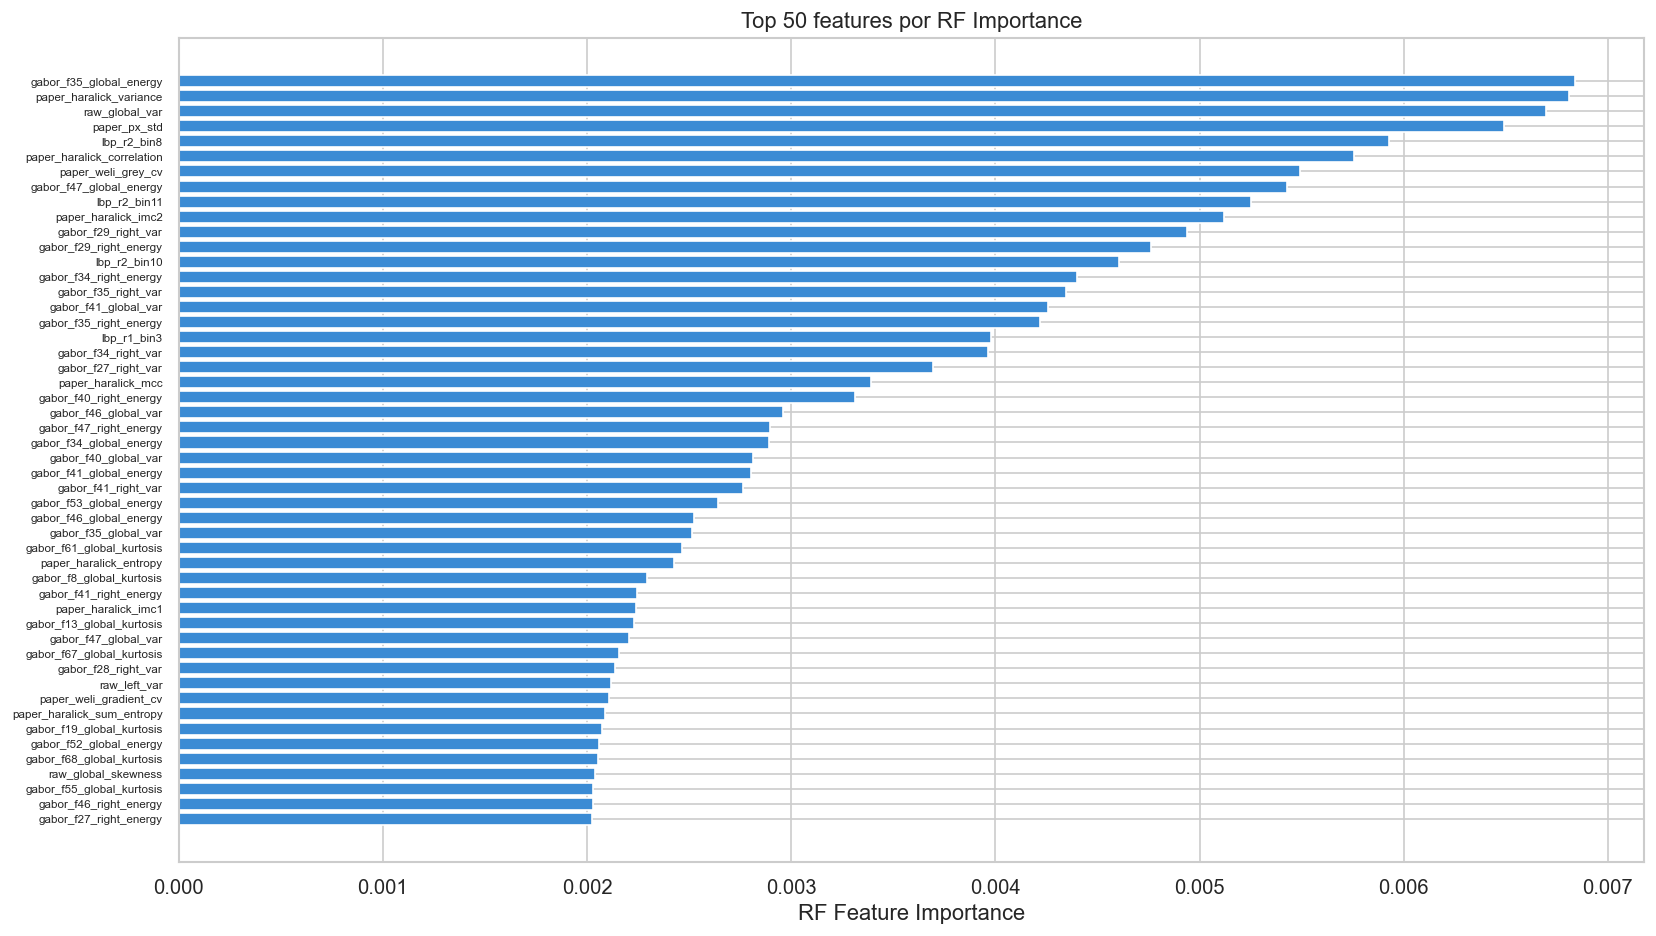


Shape train after selection: (31475, 50)
Shape test  after selection: (11200, 50)


In [21]:
## Train/Test split + RF Feature Selection
# Split on patient level
# Identify patients with forced GT with label=0
problem_patients = (
    df[(df['roi_idx'] > 100) & (df[TARGET_COL] == 0)]
    ['patient_id'].unique().tolist()
)

# Split over the other patients
remaining_patients = [p for p in sampled['patient_id'].unique()
                      if p not in problem_patients]

patients_train, patients_test_remaining = train_test_split(
    remaining_patients, test_size=0.2, random_state=RANDOM_STATE
)

# Add problematic patients to test
patients_test = list(patients_test_remaining) + problem_patients

total = len(patients_train) + len(patients_test)
print(f"Real split : {len(patients_train)/total*100:.1f}% / {len(patients_test)/total*100:.1f}%")

# Train: sampled + forced GT
rpf_check = df.groupby(['patient_id','serie_id','frame_id'])['roi_idx'].count()

train_df = df[df['patient_id'].isin(patients_train)].copy()
# Test: only sampled, without forced GT
test_df  = sampled[sampled['patient_id'].isin(patients_test)].copy()

print(f'Train ROIs : {len(train_df):,}  '
      f'(label=1: {(train_df[TARGET_COL]==1).sum():,}, '
      f'label=-1: {(train_df[TARGET_COL]==-1).sum():,})')
print(f'Test ROIs  : {len(test_df):,}   '
      f'(label=1: {(test_df[TARGET_COL]==1).sum():,}, '
      f'label=-1: {(test_df[TARGET_COL]==-1).sum():,})')
print(f'Train patients: {len(patients_train)} | Test patients: {len(patients_test)}')

# Leakage check
overlap = set(patients_train) & set(patients_test)
print(f"Leakage check: {len(overlap)} patients in both {'✓' if len(overlap)==0 else 'X'}")

# Prepare X/y 
# Remove undetermined samples from training
train_df = train_df[train_df[TARGET_COL] != -1].copy()
# Map -1 → 0 in test (undetermined = healthy)
test_df[TARGET_COL]  = test_df[TARGET_COL].replace(-1, 0)

X_train = train_df[feature_cols].fillna(train_df[feature_cols].median())
y_train = train_df[TARGET_COL]
X_test  = test_df[feature_cols].fillna(X_train.median())
y_test  = test_df[TARGET_COL]

# Scaling
scaler_minmax = MinMaxScaler()
X_train_scaled = scaler_minmax.fit_transform(X_train)
X_test_scaled  = scaler_minmax.transform(X_test)

# RF Feature Importance
rf_selector = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_selector.fit(X_train_scaled, y_train)
importances       = pd.Series(rf_selector.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

TOP_K        = 50
top_features = importances_sorted.head(TOP_K).index.tolist()

# Visual plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(TOP_K), importances_sorted.head(TOP_K).values[::-1], color='#3B8BD4')
ax.set_yticks(range(TOP_K))
ax.set_yticklabels(importances_sorted.head(TOP_K).index[::-1], fontsize=7)
ax.set_xlabel('RF Feature Importance')
ax.set_title(f'Top {TOP_K} features por RF Importance')
plt.tight_layout()
plt.show()

# Apply selection
X_train_sel = X_train_scaled[:, [feature_cols.index(f) for f in top_features]]
X_test_sel  = X_test_scaled[:,  [feature_cols.index(f) for f in top_features]]
print(f'\nShape train after selection: {X_train_sel.shape}')
print(f'Shape test  after selection: {X_test_sel.shape}')

In [29]:
## Save Top 50 features
top50_cols = top_features 

# Train y test with only 50 features +metadata
train_out = train_df[['roi_name', 'patient_id', 'serie_id', 'frame_id', 
                       'roi_idx', 'is_forced_gt', TARGET_COL] + top50_cols].copy()

test_out  = test_df[['roi_name', 'patient_id', 'serie_id', 'frame_id', 
                      'roi_idx', 'is_forced_gt', TARGET_COL] + top50_cols].copy()

# Save csv
train_out.to_csv('train_top50_features_ORIENTED.csv', index=False)
test_out.to_csv('test_top50_features_ORIENTED.csv', index=False)

# save features list
with open('top50_feature_names.pkl', 'wb') as f:
    pickle.dump(top50_cols, f)

print(f'Train CSV : {train_out.shape}  → train_top50_features.csv')
print(f'Test CSV  : {test_out.shape}   → test_top50_features.csv')

Train CSV : (31475, 57)  → train_top50_features.csv
Test CSV  : (11200, 57)   → test_top50_features.csv


In [25]:
scaler_minmax = MinMaxScaler()

X_train_sel_norm = scaler_minmax.fit_transform(X_train_sel)
X_test_sel_norm  = scaler_minmax.transform(X_test_sel)

# Verificar rango
print(f"Train min: {X_train_sel_norm.min():.3f}  max: {X_train_sel_norm.max():.3f}")
print(f"Test  min: {X_test_sel_norm.min():.3f}  max: {X_test_sel_norm.max():.3f}")

# ── Exportar ──────────────────────────────────────────────────
train_pos = X_train_sel_norm[y_train.values == 1]
train_neg = X_train_sel_norm[y_train.values == 0]
test_pos  = X_test_sel_norm[y_test.values == 1]
test_neg  = X_test_sel_norm[y_test.values == 0]

OUTPUT_DIR = Path(r"C:\Users\mluser\IPA_ML\notebooks\notebooks\csv_files\oriented_rois\ucasML")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame(train_pos).to_csv(OUTPUT_DIR / "train_positive.csv", header=False, index=False)
pd.DataFrame(train_neg).to_csv(OUTPUT_DIR / "train_negative.csv", header=False, index=False)
pd.DataFrame(test_pos).to_csv(OUTPUT_DIR / "test_positive.csv",   header=False, index=False)
pd.DataFrame(test_neg).to_csv(OUTPUT_DIR / "test_negative.csv",   header=False, index=False)

print(f"\ntrain_positive : {len(train_pos):,} rows")
print(f"train_negative : {len(train_neg):,} rows")
print(f"test_positive  : {len(test_pos):,} rows")
print(f"test_negative  : {len(test_neg):,} rows")

Train min: 0.000  max: 1.000
Test  min: -0.000  max: 1.247

train_positive : 2,108 rows
train_negative : 29,367 rows
test_positive  : 455 rows
test_negative  : 10,745 rows


In [26]:
with open('scaler_minmax_downsampled.pkl', 'wb') as f:
    pickle.dump(scaler_minmax, f)
print("Scaler saved ✓")

Scaler saved ✓


## 10 · Feature-feature correlation heatmap

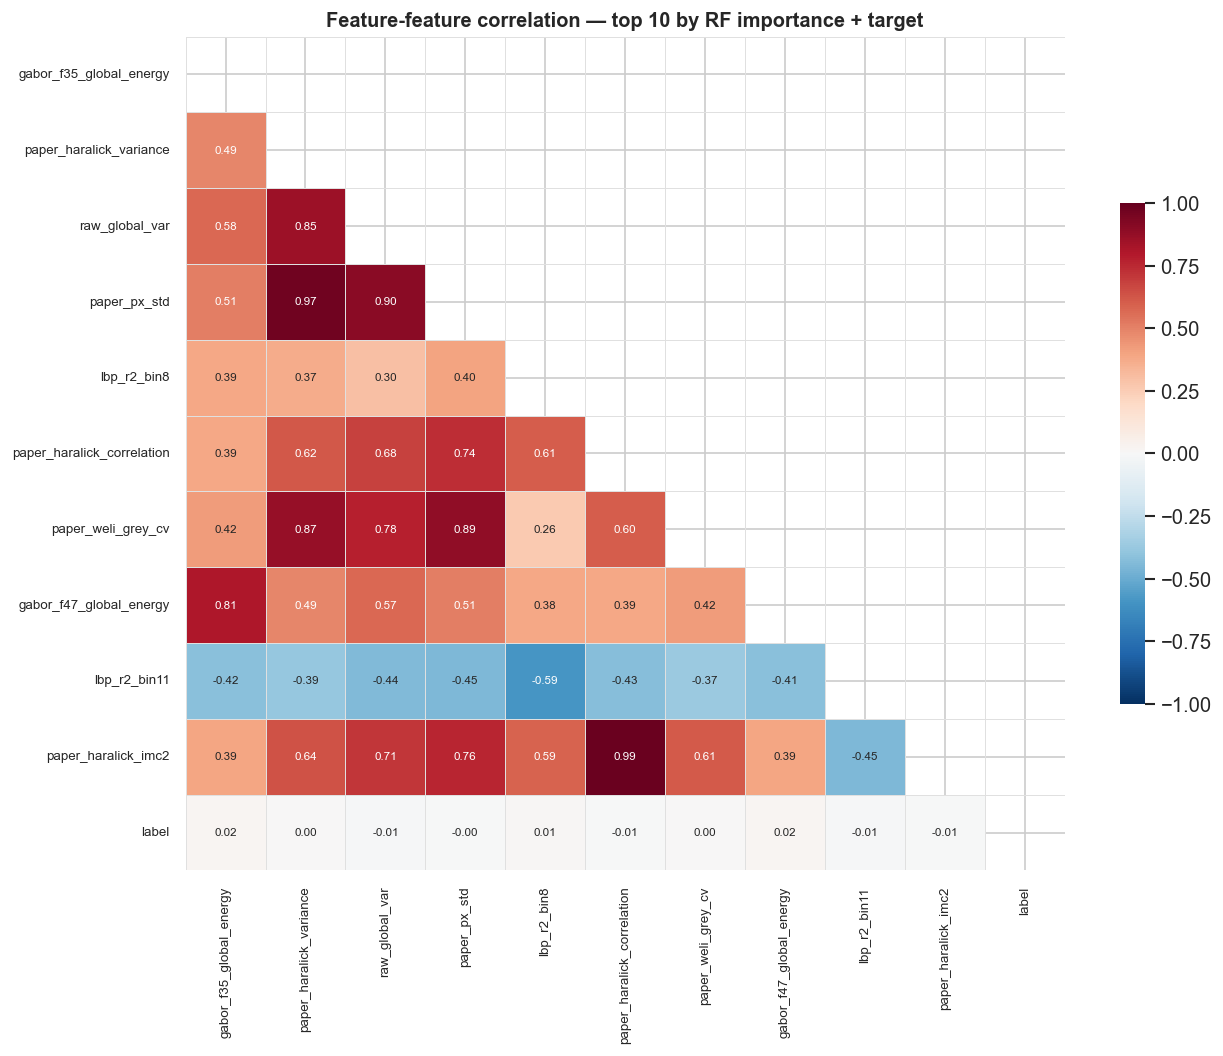

In [22]:
## Feature-feature correlation heatmap (top 20 by RF importance)
TOP_CORR = 10
top20_corr = importances_sorted.head(TOP_CORR).index.tolist()
cols_with_target = top20_corr + [TARGET_COL]
corr_matrix = sampled[cols_with_target].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 7},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='#e0e0e0', ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title(f'Feature-feature correlation — top {TOP_CORR} by RF importance + target',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.show()

## 9. Outlier detection

In [27]:
X_clean      = sampled[feature_cols].fillna(sampled[feature_cols].median())
z_scores     = np.abs(stats.zscore(X_clean, nan_policy='omit'))
outlier_mask = (z_scores > 4).any(axis=1)

print(f'Rows |z|>4 in any feature: {outlier_mask.sum()} ({outlier_mask.sum()/len(sampled)*100:.1f}%)')
print('By class:')
print(sampled.loc[outlier_mask, TARGET_COL].value_counts().rename({0:'Healthy', 1:'Stenosis', -1:'Undetermined'}))

out_per_feat = pd.Series((z_scores > 4).sum(axis=0), index=feature_cols)
print('\nTop 10 features with most outlier rows:')
print(out_per_feat.sort_values(ascending=False).head(10).to_string())

Rows |z|>4 in any feature: 24147 (53.9%)
By class:
label
Healthy         20788
Undetermined     1884
Stenosis         1475
Name: count, dtype: int64

Top 10 features with most outlier rows:
lbp_r1_bin0               562
gabor_f18_right_energy    545
gabor_f12_right_energy    544
gabor_f12_right_var       543
gabor_f18_right_var       540
gabor_f30_right_energy    532
gabor_f30_right_var       531
gabor_f24_right_var       528
gabor_f24_right_energy    528
gabor_f48_right_energy    525


In [28]:
# avg of features outlier per ROI
n_outlier_feats_per_roi = (z_scores > 4).sum(axis=1)
print("Features outlier por ROI:")
print(pd.Series(n_outlier_feats_per_roi).describe())
print(f"\nROIs with >10 features outlier : {(n_outlier_feats_per_roi > 10).sum()}")
print(f"ROIs with >50 features outlier : {(n_outlier_feats_per_roi > 50).sum()}")
print(f"ROIs with >100 features outlier: {(n_outlier_feats_per_roi > 100).sum()}")

Features outlier por ROI:
count    44800.000000
mean         6.763906
std         13.194911
min          0.000000
25%          0.000000
50%          1.000000
75%          7.000000
max        223.000000
dtype: float64

ROIs with >10 features outlier : 8673
ROIs with >50 features outlier : 929
ROIs with >100 features outlier: 38
